**Prática de Segmentação de imagens**

In [2]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Faça a plotagem do histograma da imagem, observando o histograma, escolha um valor para definir um threshold

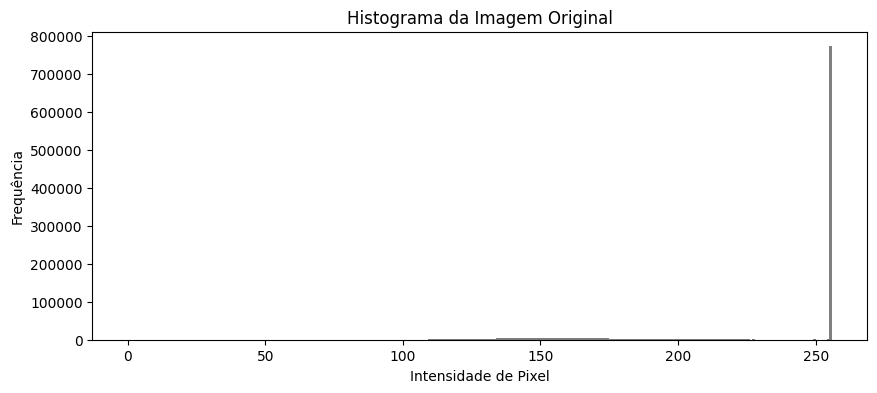

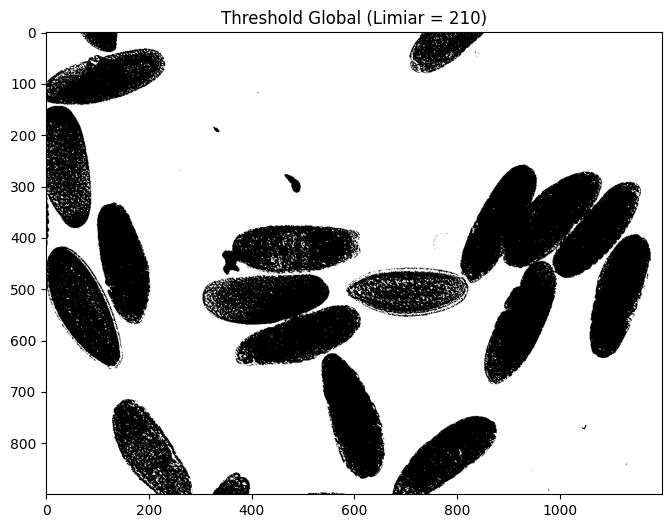

In [7]:

img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)


plt.figure(figsize=(10, 4))
plt.hist(img1.ravel(), bins=256, range=[0, 256], color='gray')
plt.title('Histograma da Imagem Original')
plt.xlabel('Intensidade de Pixel')
plt.ylabel('Frequência')
plt.show()

valor_limiar = 210


_, img_thresh = cv2.threshold(img1, valor_limiar, 255, cv2.THRESH_BINARY)


plt.figure(figsize=(8, 6))
plt.imshow(img_thresh, cmap='gray', vmin=0, vmax=255)
plt.title(f'Threshold Global (Limiar = {valor_limiar})')
plt.show()

2)	Segmentação utilizando a técnica de Threshold Adaptativo (implementar o algortimo). Faça a aplicação do Threshold com e sem suavização prévia

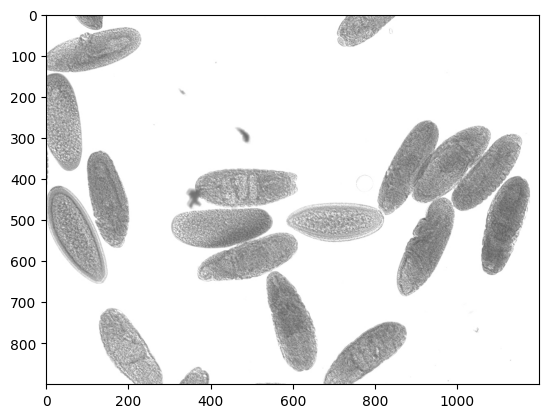

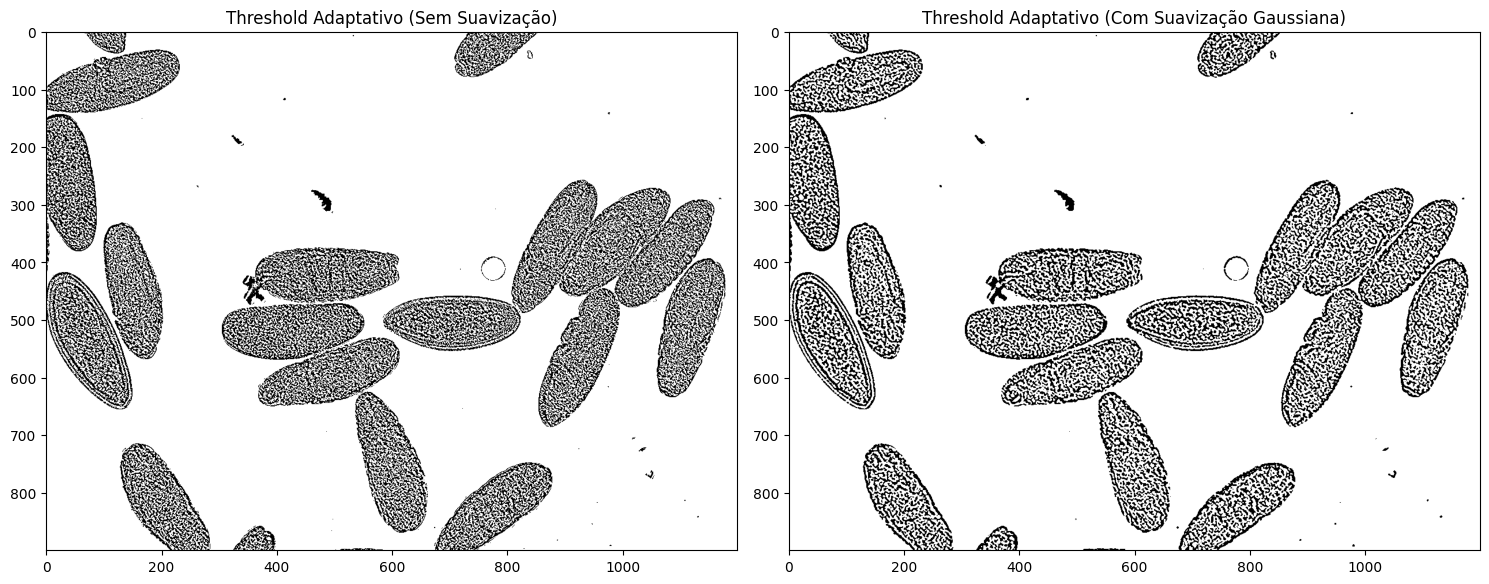

In [5]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255)


thresh_adapt_sem = cv2.adaptiveThreshold(
    img1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2
)


img_suavizada = cv2.GaussianBlur(img1, (5, 5), 0)
thresh_adapt_com = cv2.adaptiveThreshold(
    img_suavizada, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].imshow(thresh_adapt_sem, cmap='gray')
axes[0].set_title('Threshold Adaptativo (Sem Suavização)')

axes[1].imshow(thresh_adapt_com, cmap='gray')
axes[1].set_title('Threshold Adaptativo (Com Suavização Gaussiana)')

plt.tight_layout()
plt.show()


3) Segmentação utilizando a técnica de Otsu (implementar) . Faça a aplicação do Threshold com e sem suavização prévia. Mostre um gráfico com o histograma juntamente com a variância entre classes (Exemplo: https://en.wikipedia.org/wiki/File:Otsu%27s_Method_Visualization.gif)

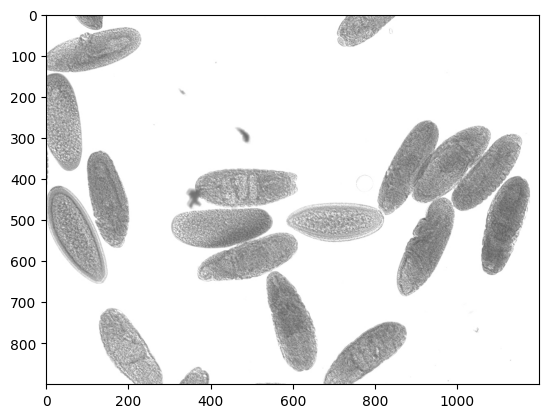

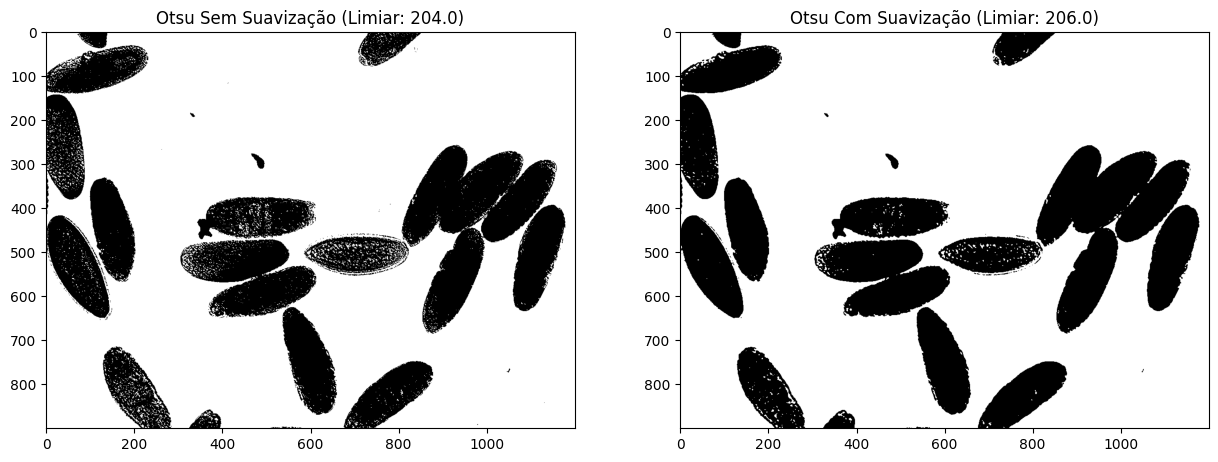

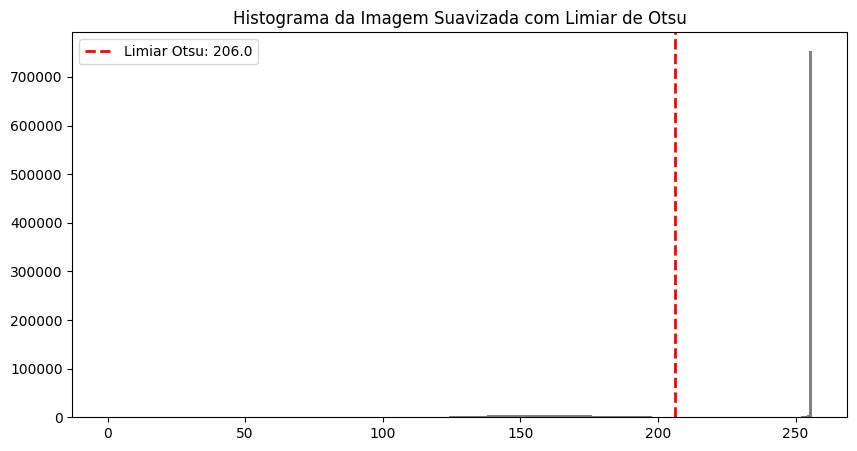

In [6]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img1, cmap='gray', vmin=0, vmax=255)

#Otsu sem suavização 
valor_otsu_sem, th_otsu_sem = cv2.threshold(img1, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Otsu com suavização 
blur = cv2.GaussianBlur(img1, (5,5), 0)
valor_otsu_com, th_otsu_com = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(th_otsu_sem, cmap='gray')
axes[0].set_title(f'Otsu Sem Suavização (Limiar: {valor_otsu_sem})')
axes[1].imshow(th_otsu_com, cmap='gray')
axes[1].set_title(f'Otsu Com Suavização (Limiar: {valor_otsu_com})')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(blur.ravel(), bins=256, range=[0, 256], color='gray')
plt.axvline(x=valor_otsu_com, color='r', linestyle='dashed', linewidth=2, label=f'Limiar Otsu: {valor_otsu_com}')
plt.title('Histograma da Imagem Suavizada com Limiar de Otsu')
plt.legend()
plt.show()

In [ ]:
4)	Aplique o Otsu para a imagem HE.jpg, madrill.tiff e  Lenna.jpg (use antes a conversão da imagem para tons de cinza)

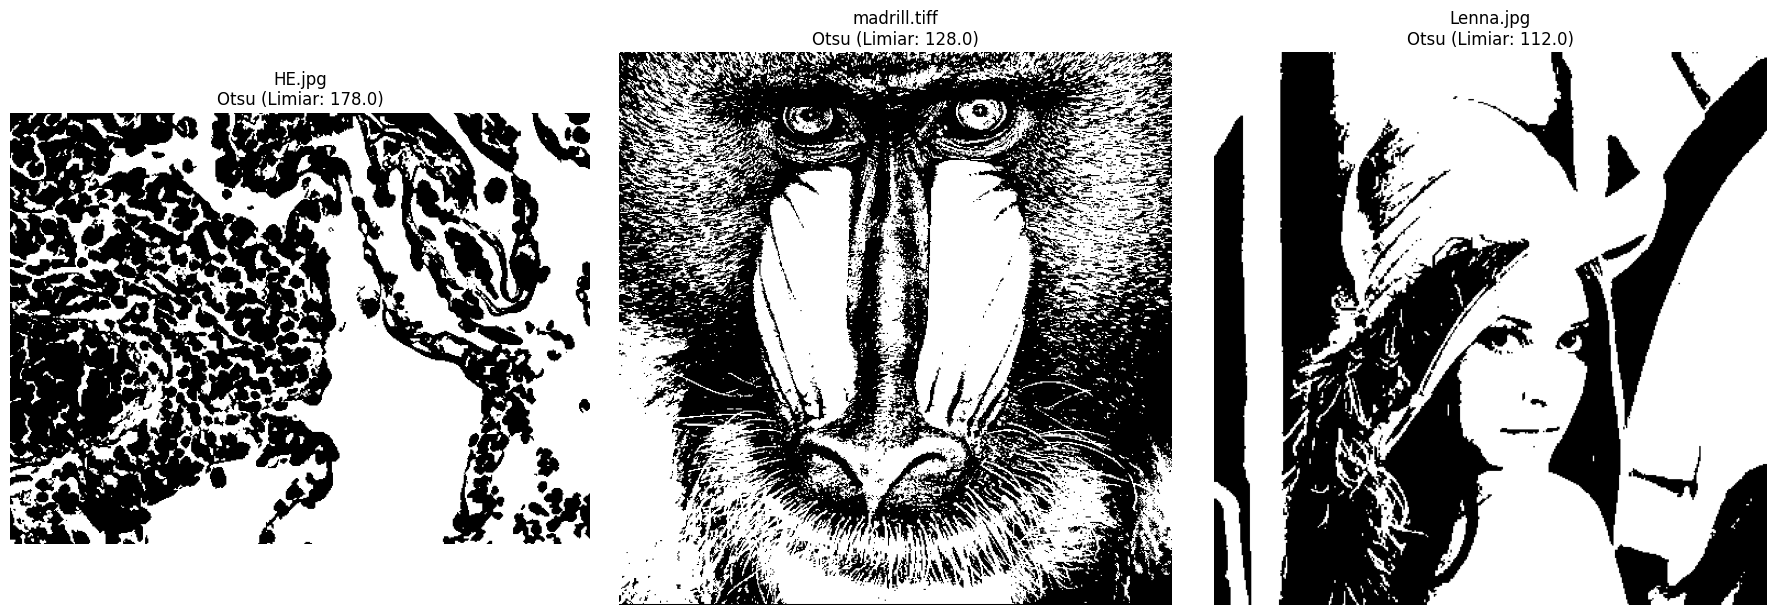

In [8]:
imagens = ["HE.jpg", "madrill.tiff", "Lenna.jpg"]

plt.figure(figsize=(18, 6))

for i, nome_img in enumerate(imagens):
    img = cv2.imread(nome_img, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"Erro: Não foi possível carregar a imagem {nome_img}. Verifique se o arquivo está no diretório correto.")
        continue
        
    
    valor_otsu, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    plt.subplot(1, 3, i+1)
    plt.imshow(img_otsu, cmap='gray')
    plt.title(f'{nome_img}\nOtsu (Limiar: {valor_otsu})')
    plt.axis('off')

plt.tight_layout()
plt.show()